In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, roc_curve
print(" Libraries loaded")


 Libraries loaded


## 1. Load Saved Artifacts

In [2]:
best_model     = joblib.load('trained_catboost_model.pkl')
scaler         = joblib.load('scaler.pkl')
ohe            = joblib.load('ohe_compound.pkl')
label_encoders = joblib.load('label_encoders.pkl')
feature_cols   = joblib.load('feature_columns.pkl')

print(" Model loaded:", type(best_model).__name__)
print(" Scaler, OHE, Label Encoders, Feature columns loaded")


 Model loaded: XGBClassifier
 Scaler, OHE, Label Encoders, Feature columns loaded


## 2. Load & Preprocess Test Data
> **Critical:** Use the SAME encoders/scaler fitted on training data — never refit on test!

In [3]:
test_df = pd.read_csv('test.csv')
test_id = test_df['id'].copy()
print(f"Test shape: {test_df.shape}")
test_df.head(3)


Test shape: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0


In [4]:
# ── Apply SAME Label Encoders (fitted on train) ──
for col, le in label_encoders.items():
    # Handle unseen labels gracefully
    known_classes = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(
        lambda x: x if x in known_classes else le.classes_[0])
    test_df[col] = le.transform(test_df[col])
    print(f"Label-encoded: {col}")

# ── Apply SAME OHE (fitted on train) ──
encoded_data = ohe.transform(test_df[['Compound']].astype(str))
encoded_df = pd.DataFrame(encoded_data,
                           columns=ohe.get_feature_names_out(['Compound']),
                           index=test_df.index)
test_df = pd.concat([test_df, encoded_df], axis=1).drop(columns=['Compound'])
print("One-hot encoded: Compound")

# ── Select same features as training ──
X_test = test_df[feature_cols]

# ── Apply SAME Scaler (fitted on train) ──
X_test_scaled = scaler.transform(X_test)

print(f"\n X_test shape: {X_test_scaled.shape}")


Label-encoded: Driver
Label-encoded: Race
One-hot encoded: Compound

 X_test shape: (188165, 18)


## 3. Generate Predictions

In [5]:
# Use predict_proba (not predict) for ROC-AUC — gives probability of class 1
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Predictions: {len(y_pred_proba):,}")
print(f"Min: {y_pred_proba.min():.4f} | Max: {y_pred_proba.max():.4f}")
print(f"Mean: {y_pred_proba.mean():.4f} | Std: {y_pred_proba.std():.4f}")


Predictions: 188,165
Min: 0.0000 | Max: 0.9990
Mean: 0.1982 | Std: 0.3001


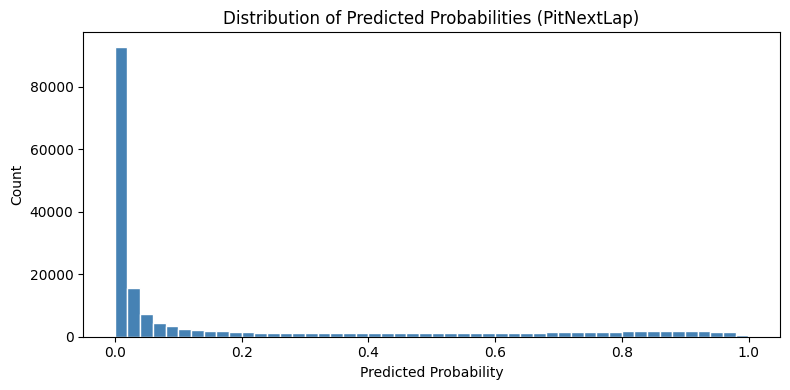

In [6]:
# Distribution of predicted probabilities
plt.figure(figsize=(8, 4))
plt.hist(y_pred_proba, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Predicted Probabilities (PitNextLap)')
plt.xlabel('Predicted Probability'); plt.ylabel('Count')
plt.tight_layout(); plt.show()


## 4. Create Submission File

In [7]:
submission = pd.DataFrame({
    'id': test_id,
    'PitNextLap': y_pred_proba
})

submission.to_csv('submission.csv', index=False)

print("=" * 50)
print("  SUBMISSION SUMMARY")
print("=" * 50)
print(f"  Total rows    : {len(submission):,}")
print(f"  Columns       : {list(submission.columns)}")
print(f"  Null values   : {submission.isnull().sum().sum()}")
print("=" * 50)
print("   submission.csv is ready!")
print("=" * 50)
submission.head(10)


  SUBMISSION SUMMARY
  Total rows    : 188,165
  Columns       : ['id', 'PitNextLap']
  Null values   : 0
   submission.csv is ready!


,id,PitNextLap
0,439140,0.003686
1,439141,0.008779
2,439142,0.004544
3,439143,0.173322
4,439144,0.891711
5,439145,0.493904
6,439146,0.001384
7,439147,0.006974
8,439148,0.022007
9,439149,0.000997
